# 06 — Hybrid Legal Retrieval and Cross-Encoder Reranking

This notebook builds and evaluates the retrieval layer for the legal RAG system.
It creates a leakage-controlled judgment corpus, combines dense semantic search
and BM25 with Reciprocal Rank Fusion (RRF), and reranks candidates with a
Cross-Encoder.

The retrieval stack is evaluated separately from Qwen generation using held-out
synthetic legal queries and known relevant judgments. This separation makes it
possible to diagnose whether a later RAG failure comes from retrieval or generation.

Pipeline:

1. Rebuild retrieval-sized chunks from the original judgments.
2. Create normalized dense embeddings and a FAISS cosine-similarity index.
3. Build a BM25 lexical retriever.
4. Fuse dense and BM25 rankings using RRF.
5. Rerank the strongest hybrid candidates with a Cross-Encoder.
6. Evaluate Recall@K, MRR@10, nDCG@10 and latency.



## 1. Environment setup



In [1]:
# Uncomment and run once if required, then restart the kernel.
%pip install -U "sentence-transformers>=5.1" "faiss-cpu>=1.12" \
    "rank-bm25>=0.2.2" "transformers==5.6.2" pandas numpy matplotlib \
    seaborn tqdm python-dotenv packaging



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 39.4 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.11.1
    Uninstalling matplotlib-3.11.1:
      Successfully uninstalled matplotlib-3.11.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
depth-anything-3 0.0.0 requires opencv-python, which is not installed.
ultralytics 8.4.45 requires opencv-python>=4.6.0, which is not installed.
depth-anything-3 0.0.0 requires numpy<2, but you have numpy 2.5.3 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


## 2. Configuration

The default query benchmark uses 25 cases from each test partition—the same
sample size used in notebook 05. Set `LEGAL_RETRIEVAL_CASE_LIMIT=0` for all
held-out cases. Index artifacts are cached and reused when the configuration
and split manifests have not changed.



In [2]:
import os
from pathlib import Path

os.environ.setdefault("CUDA_VISIBLE_DEVICES", os.getenv("LEGAL_CUDA_VISIBLE_DEVICES", "1"))
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

PROJECT_ROOT = Path(os.getenv(
    "LEGALMIND_PROJECT_ROOT",
    "/data2/user_data/sg57092c/LLM_finetune",
)).expanduser()
ZIP_PATH = Path(os.getenv(
    "LEGAL_DATASET_ZIP",
    str(PROJECT_ROOT / "dataset" / "dataset" / "legal_dataset.zip"),
)).expanduser()
SPLIT_DIR = PROJECT_ROOT / "data" / "splits"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "qwen3_8b_long_document"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "hybrid_legal_retrieval"
INDEX_DIR = ARTIFACT_DIR / "index"
EVALUATION_DIR = ARTIFACT_DIR / "evaluation"

DENSE_MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"
RERANKER_MODEL_NAME = "cross-encoder/ms-marco-MiniLM-L-6-v2"
RETRIEVAL_CHUNK_TOKENS = 320
RETRIEVAL_CHUNK_OVERLAP = 48
EMBEDDING_BATCH_SIZE = 64
RERANK_BATCH_SIZE = 32
DENSE_CANDIDATES = 100
BM25_CANDIDATES = 100
RRF_CANDIDATES = 40
RERANK_TOP_N = 30
FINAL_TOP_K = 10
RRF_K = 60
QUERY_MAX_WORDS = 80
CASE_LIMIT_PER_PARTITION = int(os.getenv("LEGAL_RETRIEVAL_CASE_LIMIT", "25"))
FORCE_REBUILD_INDEX = os.getenv("LEGAL_FORCE_REBUILD_INDEX", "0") == "1"
RANDOM_SEED = 42
TEST_PARTITIONS = ("test_in_abs", "test_in_ext_expert", "test_uk_abs")

MANIFEST_FILES = {
    "train": "train_manifest.jsonl",
    "validation": "validation_manifest.jsonl",
    "test_in_abs": "test_in_abs_manifest.jsonl",
    "test_in_ext_expert": "test_in_ext_expert_manifest.jsonl",
    "test_uk_abs": "test_uk_abs_manifest.jsonl",
}

for directory in (ARTIFACT_DIR, INDEX_DIR, EVALUATION_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print("Dataset ZIP       :", ZIP_PATH)
print("Dense model       :", DENSE_MODEL_NAME)
print("Reranker          :", RERANKER_MODEL_NAME)
print("Query evaluation  :", "FULL" if CASE_LIMIT_PER_PARTITION == 0 else CASE_LIMIT_PER_PARTITION)
print("Visible GPU(s)    :", os.environ["CUDA_VISIBLE_DEVICES"])



Dataset ZIP       : /data2/user_data/sg57092c/LLM_finetune/dataset/dataset/legal_dataset.zip
Dense model       : sentence-transformers/all-mpnet-base-v2
Reranker          : cross-encoder/ms-marco-MiniLM-L-6-v2
Query evaluation  : 25
Visible GPU(s)    : 1


## 3. Imports and reproducibility



In [3]:
import hashlib
import json
import math
import random
import re
import time
import unicodedata
import zipfile
from collections import defaultdict

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from dotenv import load_dotenv
from rank_bm25 import BM25Okapi
from sentence_transformers import CrossEncoder, SentenceTransformer
from tqdm.auto import tqdm

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 160)

if not ZIP_PATH.exists() or not zipfile.is_zipfile(ZIP_PATH):
    raise FileNotFoundError(f"Valid legal dataset ZIP not found: {ZIP_PATH}")
if not torch.cuda.is_available():
    raise RuntimeError("A CUDA GPU is recommended for corpus encoding and reranking.")

load_dotenv(PROJECT_ROOT / ".env")
hf_token = os.getenv("HF_TOKEN")

free_bytes, total_bytes = torch.cuda.mem_get_info(0)
print("GPU:", torch.cuda.get_device_name(0))
print(f"GPU memory: {free_bytes / 1024**3:.2f} GiB free / {total_bytes / 1024**3:.2f} GiB")



GPU: NVIDIA H100 80GB HBM3
GPU memory: 78.68 GiB free / 79.19 GiB


## 4. Load and validate split manifests



In [4]:
manifests = {}
manifest_paths = {}
for partition, filename in MANIFEST_FILES.items():
    path = SPLIT_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f"Missing manifest: {path}. Run notebook 02 first.")
    frame = pd.read_json(path, lines=True)
    required = {
        "case_id", "dataset", "jurisdiction", "judgment_hash",
        "judgment_member", "summary_member",
    }
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f"{partition} manifest is missing {sorted(missing)}")
    frame = frame.copy()
    frame["partition"] = partition
    frame["case_id"] = frame["case_id"].astype(str)
    manifests[partition] = frame
    manifest_paths[partition] = path

manifest_summary = pd.DataFrame([
    {
        "partition": partition,
        "summary_pairs": len(frame),
        "unique_judgments": frame["judgment_hash"].nunique(),
        "datasets": ", ".join(sorted(frame["dataset"].unique())),
    }
    for partition, frame in manifests.items()
])
display(manifest_summary)

partition_hashes = {
    partition: set(frame["judgment_hash"])
    for partition, frame in manifests.items()
}
for left_index, left in enumerate(MANIFEST_FILES):
    for right in list(MANIFEST_FILES)[left_index + 1:]:
        overlap = partition_hashes[left] & partition_hashes[right]
        if overlap:
            raise ValueError(f"Leakage between {left} and {right}: {len(overlap)} judgments")
print("PASS: judgment hashes are isolated across all partitions.")



,partition,summary_pairs,unique_judgments,datasets
0,train,6303,6303,IN-Abs
1,validation,700,700,IN-Abs
2,test_in_abs,100,100,IN-Abs
3,test_in_ext_expert,100,50,IN-Ext
4,test_uk_abs,99,99,UK-Abs


PASS: judgment hashes are isolated across all partitions.


## 5. Load the dense encoder

Retrieval chunks use the embedding model's own tokenizer, preventing silent
truncation at embedding time.



In [5]:
dense_model = SentenceTransformer(
    DENSE_MODEL_NAME,
    device="cuda",
    token=hf_token or None,
)
dense_tokenizer = dense_model.tokenizer
effective_chunk_tokens = min(
    RETRIEVAL_CHUNK_TOKENS,
    int(dense_model.max_seq_length) - 16,
)
if RETRIEVAL_CHUNK_OVERLAP >= effective_chunk_tokens:
    raise ValueError("Chunk overlap must be smaller than chunk size.")
print("Dense dimension:", dense_model.get_sentence_embedding_dimension())
print("Model max length:", dense_model.max_seq_length)
print("Retrieval chunk tokens:", effective_chunk_tokens)



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Dense dimension: 768
Model max length: 384
Retrieval chunk tokens: 320


/tmp/ipykernel_2535224/3673717662.py:13: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("Dense dimension:", dense_model.get_sentence_embedding_dimension())


## 6. Text cleaning and retrieval-sized chunking



In [6]:
SENTENCE_BOUNDARY = re.compile(r"(?<=[.!?])\s+(?=[A-Z0-9\[(])")

def decode_bytes(raw):
    for encoding in ("utf-8", "utf-8-sig", "cp1252", "latin-1"):
        try:
            return raw.decode(encoding)
        except UnicodeDecodeError:
            continue
    return raw.decode("utf-8", errors="replace")

def clean_legal_text(text):
    text = unicodedata.normalize("NFKC", text)
    text = text.replace("\x00", " ").replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"(?<=\w)-[ \t]*\n[ \t]*(?=\w)", "", text)
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r" *\n *", "\n", text)
    return re.sub(r"\n{3,}", "\n\n", text).strip()

def token_ids(text):
    # verbose=False suppresses warnings while measuring long source sentences.
    return dense_tokenizer(
        text, add_special_tokens=False, truncation=False, verbose=False
    )["input_ids"]

def hard_token_chunks(text, max_tokens, overlap_tokens):
    ids = token_ids(text)
    pieces = []
    start = 0
    while start < len(ids):
        piece_ids = ids[start:start + max_tokens]
        # Decoding and re-tokenizing are not perfectly reversible for every
        # tokenizer. Shrink until the decoded text is truly within budget.
        for _ in range(20):
            decoded = dense_tokenizer.decode(
                piece_ids, skip_special_tokens=True
            ).strip()
            measured = len(token_ids(decoded))
            if measured <= max_tokens:
                break
            keep = max(1, math.floor(len(piece_ids) * max_tokens / measured) - 2)
            piece_ids = piece_ids[:keep]
        else:
            raise ValueError("Could not fit a decoded chunk within token budget.")
        if decoded:
            pieces.append(decoded)
        consumed = len(piece_ids)
        if start + consumed >= len(ids):
            break
        start += max(1, consumed - overlap_tokens)
    return pieces

def sentence_aware_chunks(text, max_tokens, overlap_tokens):
    paragraphs = [part.strip() for part in re.split(r"\n{2,}", text) if part.strip()]
    sentences = []
    for paragraph in paragraphs:
        sentences.extend(
            part.strip() for part in SENTENCE_BOUNDARY.split(paragraph) if part.strip()
        )
    expanded = []
    for sentence in sentences:
        if len(token_ids(sentence)) <= max_tokens:
            expanded.append(sentence)
        else:
            expanded.extend(hard_token_chunks(sentence, max_tokens, overlap_tokens))

    chunks = []
    current = []
    for sentence in expanded:
        candidate = " ".join(current + [sentence]).strip()
        if current and len(token_ids(candidate)) > max_tokens:
            chunks.append(" ".join(current).strip())
            overlap_sentences = []
            overlap_size = 0
            for previous in reversed(current):
                size = len(token_ids(previous))
                if overlap_sentences and overlap_size + size > overlap_tokens:
                    break
                overlap_sentences.insert(0, previous)
                overlap_size += size
                if overlap_size >= overlap_tokens:
                    break
            current = overlap_sentences + [sentence]
        else:
            current.append(sentence)
    if current:
        chunks.append(" ".join(current).strip())

    bounded = []
    for chunk in chunks:
        if len(token_ids(chunk)) <= max_tokens:
            bounded.append(chunk)
        else:
            bounded.extend(hard_token_chunks(chunk, max_tokens, overlap_tokens))
    return [chunk for chunk in bounded if chunk]

smoke_chunks = sentence_aware_chunks(
    "The appeal was dismissed. Costs were awarded. " * 1000,
    effective_chunk_tokens,
    RETRIEVAL_CHUNK_OVERLAP,
)
assert smoke_chunks and all(len(token_ids(chunk)) <= effective_chunk_tokens for chunk in smoke_chunks)
print("PASS: retrieval chunking respects the dense-model token budget.")



PASS: retrieval chunking respects the dense-model token budget.


## 7. Build or load the retrieval corpus

Only original judgment text is indexed. Human reference summaries are kept out
of the corpus and are used solely to construct the held-out retrieval benchmark.



In [7]:
CORPUS_PATH = INDEX_DIR / "retrieval_corpus.jsonl"
EMBEDDINGS_PATH = INDEX_DIR / "dense_embeddings.npy"
FAISS_PATH = INDEX_DIR / "dense_index.faiss"
INDEX_METADATA_PATH = INDEX_DIR / "index_metadata.json"

def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

manifest_signatures = {
    partition: sha256_file(path)
    for partition, path in manifest_paths.items()
}
index_config = {
    "dense_model": DENSE_MODEL_NAME,
    "chunk_tokens": effective_chunk_tokens,
    "chunk_overlap": RETRIEVAL_CHUNK_OVERLAP,
    "manifest_sha256": manifest_signatures,
}

cache_valid = all(path.exists() for path in (
    CORPUS_PATH, EMBEDDINGS_PATH, FAISS_PATH, INDEX_METADATA_PATH
))
if cache_valid:
    with open(INDEX_METADATA_PATH, encoding="utf-8") as file:
        cached_metadata = json.load(file)
    cache_valid = cached_metadata.get("index_config") == index_config
cache_valid = cache_valid and not FORCE_REBUILD_INDEX

def write_corpus():
    all_manifest_rows = pd.concat(manifests.values(), ignore_index=True)
    unique_judgments = (
        all_manifest_rows.sort_values(["partition", "dataset", "case_id"])
        .drop_duplicates("judgment_hash", keep="first")
    )
    records = []
    with zipfile.ZipFile(ZIP_PATH) as archive:
        for row in tqdm(
            unique_judgments.itertuples(index=False),
            total=len(unique_judgments),
            desc="Chunking judgments",
        ):
            judgment = clean_legal_text(decode_bytes(archive.read(row.judgment_member)))
            chunks = sentence_aware_chunks(
                judgment,
                effective_chunk_tokens,
                RETRIEVAL_CHUNK_OVERLAP,
            )
            for chunk_index, text in enumerate(chunks):
                records.append({
                    "doc_id": f"{row.dataset}:{row.case_id}:retrieval-{chunk_index:04d}",
                    "case_key": f"{row.dataset}::{row.case_id}::{row.judgment_hash}",
                    "case_id": str(row.case_id),
                    "dataset": row.dataset,
                    "jurisdiction": row.jurisdiction,
                    "source_partition": row.partition,
                    "judgment_hash": row.judgment_hash,
                    "judgment_member": row.judgment_member,
                    "chunk_index": chunk_index,
                    "total_chunks": len(chunks),
                    "text": text,
                    "embedding_tokens": len(token_ids(text)),
                })
    if not records:
        raise ValueError("No retrieval corpus records were created.")
    with open(CORPUS_PATH, "w", encoding="utf-8") as file:
        for record in records:
            file.write(json.dumps(record, ensure_ascii=False) + "\n")
    return records

def read_jsonl(path):
    records = []
    with open(path, encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as error:
                raise ValueError(f"Invalid JSON: {path}, line {line_number}") from error
    return records

recover_incomplete_corpus = (
    CORPUS_PATH.exists()
    and not INDEX_METADATA_PATH.exists()
    and not FORCE_REBUILD_INDEX
)
if cache_valid:
    corpus_records = read_jsonl(CORPUS_PATH)
    print("Loaded cached retrieval corpus.")
elif recover_incomplete_corpus:
    # Reuse a corpus written before a later validation/indexing failure.
    corpus_records = read_jsonl(CORPUS_PATH)
    print("Recovered the existing corpus; the 14-minute ZIP pass is not repeated.")
else:
    corpus_records = write_corpus()
    print("Built retrieval corpus.")

def repair_oversized_corpus_records(records):
    expanded = []
    repaired_records = 0
    for original in records:
        record = dict(original)
        measured = len(token_ids(record["text"]))
        if measured <= effective_chunk_tokens:
            record["embedding_tokens"] = measured
            expanded.append(record)
            continue
        repaired_records += 1
        for piece in hard_token_chunks(
            record["text"], effective_chunk_tokens, RETRIEVAL_CHUNK_OVERLAP
        ):
            child = dict(record)
            child["text"] = piece
            child["embedding_tokens"] = len(token_ids(piece))
            expanded.append(child)

    # Splitting may change chunk counts, so rebuild stable IDs per judgment.
    grouped = defaultdict(list)
    for record in expanded:
        grouped[record["judgment_hash"]].append(record)
    repaired_output = []
    for judgment_records in grouped.values():
        total_chunks = len(judgment_records)
        for chunk_index, record in enumerate(judgment_records):
            record["chunk_index"] = chunk_index
            record["total_chunks"] = total_chunks
            record["doc_id"] = (
                f"{record['dataset']}:{record['case_id']}:retrieval-{chunk_index:04d}"
            )
            repaired_output.append(record)
    return repaired_output, repaired_records

corpus_records, repaired_count = repair_oversized_corpus_records(corpus_records)
if repaired_count:
    with open(CORPUS_PATH, "w", encoding="utf-8") as file:
        for record in corpus_records:
            file.write(json.dumps(record, ensure_ascii=False) + "\n")
    print(f"Repaired and rewrote {repaired_count:,} oversized corpus chunks.")

corpus_df = pd.DataFrame(corpus_records)
if corpus_df["doc_id"].duplicated().any():
    raise ValueError("Duplicate retrieval document IDs detected.")
if corpus_df["embedding_tokens"].max() > effective_chunk_tokens:
    raise ValueError("At least one retrieval chunk exceeds the embedding budget.")

display(corpus_df.groupby(["source_partition", "jurisdiction"]).agg(
    judgments=("judgment_hash", "nunique"),
    chunks=("doc_id", "size"),
    mean_tokens=("embedding_tokens", "mean"),
    max_tokens=("embedding_tokens", "max"),
).reset_index().round(2))



Loaded cached retrieval corpus.
Repaired and rewrote 81 oversized corpus chunks.


,source_partition,jurisdiction,judgments,chunks,mean_tokens,max_tokens
0,test_in_abs,India,100,2488,282.09,320
1,test_in_ext_expert,India,50,3267,242.80,320
2,test_uk_abs,United Kingdom,99,6150,289.07,320
3,train,India,6303,142226,282.91,320
4,validation,India,700,16097,283.19,320


## 8. Build or load normalized embeddings and FAISS index

L2-normalized embeddings with inner-product search are equivalent to cosine
similarity ranking.



In [10]:
def encode_documents(texts):
    method = getattr(dense_model, "encode_document", dense_model.encode)

    return method(
        texts,
        batch_size=EMBEDDING_BATCH_SIZE,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=True,
    ).astype("float32")


expected_documents = len(corpus_df)
corpus_embeddings = None
dense_index = None

# Reuse embeddings only when their row count matches the repaired corpus.
if EMBEDDINGS_PATH.exists():
    cached_embeddings = np.load(EMBEDDINGS_PATH, mmap_mode="r")

    if len(cached_embeddings) == expected_documents:
        corpus_embeddings = cached_embeddings
        print("Loaded aligned cached embeddings.")
    else:
        print(
            f"Cached embeddings are stale: "
            f"{len(cached_embeddings):,} vectors for "
            f"{expected_documents:,} corpus documents."
        )

# Re-encode only when required.
if corpus_embeddings is None:
    print("Rebuilding dense embeddings for the repaired corpus...")

    corpus_embeddings = encode_documents(
        corpus_df["text"].astype(str).tolist()
    )

    if len(corpus_embeddings) != expected_documents:
        raise ValueError(
            f"Encoder returned {len(corpus_embeddings):,} vectors "
            f"for {expected_documents:,} documents."
        )

    np.save(EMBEDDINGS_PATH, corpus_embeddings)

# Reuse FAISS only when its vector count and dimension are correct.
expected_dimension = int(corpus_embeddings.shape[1])

if FAISS_PATH.exists():
    cached_index = faiss.read_index(str(FAISS_PATH))

    if (
        cached_index.ntotal == expected_documents
        and cached_index.d == expected_dimension
    ):
        dense_index = cached_index
        print("Loaded aligned cached FAISS index.")
    else:
        print(
            f"Cached FAISS index is stale: "
            f"{cached_index.ntotal:,} vectors, dimension {cached_index.d}."
        )

# Rebuild FAISS without regenerating embeddings when possible.
if dense_index is None:
    print("Rebuilding FAISS index...")

    dense_index = faiss.IndexFlatIP(expected_dimension)
    dense_index.add(
        np.ascontiguousarray(
            np.asarray(corpus_embeddings, dtype="float32")
        )
    )
    faiss.write_index(dense_index, str(FAISS_PATH))

# Save metadata for the repaired corpus.
index_config["corpus_sha256"] = sha256_file(CORPUS_PATH)

index_metadata = {
    "index_config": index_config,
    "documents": expected_documents,
    "unique_judgments": int(
        corpus_df["judgment_hash"].nunique()
    ),
    "embedding_dimension": expected_dimension,
}

with open(INDEX_METADATA_PATH, "w", encoding="utf-8") as file:
    json.dump(index_metadata, file, indent=2)

# Final validation.
if (
    len(corpus_embeddings) != expected_documents
    or dense_index.ntotal != expected_documents
):
    raise ValueError(
        "Corpus, embedding matrix and FAISS index are not aligned."
    )

sample_size = min(1000, expected_documents)
sample_embeddings = np.asarray(
    corpus_embeddings[:sample_size],
    dtype="float32",
)

norms = np.linalg.norm(sample_embeddings, axis=1)

if not np.allclose(norms, 1.0, atol=1e-3):
    raise ValueError("Dense embeddings are not L2 normalized.")

print(
    f"PASS: corpus, embeddings and FAISS contain "
    f"{dense_index.ntotal:,} aligned normalized vectors."
)

Cached embeddings are stale: 170,147 vectors for 170,228 corpus documents.
Rebuilding dense embeddings for the repaired corpus...


Batches:   0%|          | 0/2660 [00:00<?, ?it/s]

Cached FAISS index is stale: 170,147 vectors, dimension 768.
Rebuilding FAISS index...
PASS: corpus, embeddings and FAISS contain 170,228 aligned normalized vectors.


## 9. Build the BM25 lexical index



In [11]:
BM25_TOKEN_PATTERN = re.compile(r"[A-Za-z0-9]+(?:[.'/-][A-Za-z0-9]+)*")

def bm25_tokenize(text):
    return BM25_TOKEN_PATTERN.findall(text.lower())

tokenized_corpus = [bm25_tokenize(text) for text in tqdm(
    corpus_df["text"], desc="Tokenizing BM25 corpus"
)]
bm25 = BM25Okapi(tokenized_corpus)
print(f"BM25 index ready for {len(tokenized_corpus):,} chunks.")



Tokenizing BM25 corpus:   0%|          | 0/170228 [00:00<?, ?it/s]

BM25 index ready for 170,228 chunks.


## 10. Load the Cross-Encoder reranker



In [12]:
reranker = CrossEncoder(
    RERANKER_MODEL_NAME,
    device="cuda",
    max_length=512,
    token=hf_token or None,
)
print("Reranker loaded:", RERANKER_MODEL_NAME)



config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Reranker loaded: cross-encoder/ms-marco-MiniLM-L-6-v2


## 11. Hybrid retrieval functions



In [13]:
def encode_query(query):
    method = getattr(dense_model, "encode_query", dense_model.encode)
    embedding = method(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    )
    return np.asarray(embedding, dtype="float32")

def top_indices(scores, top_n):
    top_n = min(top_n, len(scores))
    candidates = np.argpartition(-scores, top_n - 1)[:top_n]
    return candidates[np.argsort(-scores[candidates])].tolist()

def reciprocal_rank_fusion(dense_ids, bm25_ids, rrf_k=RRF_K):
    fused = defaultdict(float)
    for ranking in (dense_ids, bm25_ids):
        for rank, corpus_id in enumerate(ranking, start=1):
            fused[corpus_id] += 1.0 / (rrf_k + rank)
    return sorted(fused, key=fused.get, reverse=True), fused

def collapse_to_cases(corpus_ids, scores=None, top_k=FINAL_TOP_K):
    results = []
    seen_hashes = set()
    for rank, corpus_id in enumerate(corpus_ids):
        row = corpus_df.iloc[int(corpus_id)]
        judgment_hash = row["judgment_hash"]
        if judgment_hash in seen_hashes:
            continue
        seen_hashes.add(judgment_hash)
        results.append({
            "rank": len(results) + 1,
            "corpus_id": int(corpus_id),
            "doc_id": row["doc_id"],
            "judgment_hash": judgment_hash,
            "case_id": row["case_id"],
            "dataset": row["dataset"],
            "jurisdiction": row["jurisdiction"],
            "score": None if scores is None else float(scores[rank]),
            "text": row["text"],
        })
        if len(results) >= top_k:
            break
    return results

def retrieve(query, final_top_k=FINAL_TOP_K):
    timing = {}

    started = time.perf_counter()
    query_embedding = encode_query(query)
    dense_scores, dense_ids = dense_index.search(query_embedding, DENSE_CANDIDATES)
    dense_ids = [int(value) for value in dense_ids[0] if value >= 0]
    timing["dense_ms"] = (time.perf_counter() - started) * 1000

    started = time.perf_counter()
    bm25_scores = np.asarray(bm25.get_scores(bm25_tokenize(query)), dtype=np.float32)
    bm25_ids = top_indices(bm25_scores, BM25_CANDIDATES)
    timing["bm25_ms"] = (time.perf_counter() - started) * 1000

    started = time.perf_counter()
    fused_ids, fused_scores = reciprocal_rank_fusion(dense_ids, bm25_ids)
    hybrid_ids = fused_ids[:RRF_CANDIDATES]
    timing["fusion_ms"] = (time.perf_counter() - started) * 1000

    started = time.perf_counter()
    rerank_ids = hybrid_ids[:RERANK_TOP_N]
    pairs = [(query, corpus_df.iloc[index]["text"]) for index in rerank_ids]
    cross_scores = np.asarray(
        reranker.predict(pairs, batch_size=RERANK_BATCH_SIZE, show_progress_bar=False)
    ).reshape(-1)
    rerank_order = np.argsort(-cross_scores)
    reranked_ids = [rerank_ids[index] for index in rerank_order]
    reranked_scores = [float(cross_scores[index]) for index in rerank_order]
    timing["rerank_ms"] = (time.perf_counter() - started) * 1000

    dense_case_results = collapse_to_cases(dense_ids, top_k=final_top_k)
    bm25_case_results = collapse_to_cases(bm25_ids, top_k=final_top_k)
    hybrid_case_results = collapse_to_cases(hybrid_ids, top_k=final_top_k)
    reranked_case_results = collapse_to_cases(
        reranked_ids, scores=reranked_scores, top_k=final_top_k
    )
    timing["total_ms"] = sum(timing.values())
    return {
        "dense": dense_case_results,
        "bm25": bm25_case_results,
        "hybrid_rrf": hybrid_case_results,
        "cross_encoder": reranked_case_results,
        "timing": timing,
    }

smoke_result = retrieve("When may a court dismiss an appeal under constitutional law?", 3)
for strategy in ("dense", "bm25", "hybrid_rrf", "cross_encoder"):
    assert len(smoke_result[strategy]) == 3
print("PASS: dense, BM25, RRF and reranking smoke test completed.")


PASS: dense, BM25, RRF and reranking smoke test completed.


## 12. Construct held-out retrieval queries

Each query is a shortened passage from a held-out human summary. The complete
summary is never indexed. The relevant item is the judgment from which that
summary was written. This is a reproducible synthetic retrieval benchmark;
production evaluation should later add real user queries and relevance labels.



In [14]:
def case_key(record):
    return f"{record['dataset']}::{record['case_id']}::{record['judgment_hash']}"

def query_from_summary(summary):
    cleaned = clean_legal_text(summary)
    sentences = [
        part.strip() for part in SENTENCE_BOUNDARY.split(cleaned) if part.strip()
    ]
    query = " ".join(sentences[:2]) if sentences else cleaned
    return " ".join(query.split()[:QUERY_MAX_WORDS])

query_rows = []
for partition in TEST_PARTITIONS:
    references_path = PROCESSED_DIR / f"{partition}_references.jsonl"
    if not references_path.exists():
        raise FileNotFoundError(f"Missing references: {references_path}. Run notebook 03.")
    references = read_jsonl(references_path)
    for record in references:
        record["case_key"] = case_key(record)
    reference_df = pd.DataFrame(references).sort_values(
        ["case_key", "reference_id"]
    ).drop_duplicates("case_key", keep="first")

    available_keys = sorted(reference_df["case_key"].unique())
    rng = random.Random(RANDOM_SEED + sum(ord(char) for char in partition))
    rng.shuffle(available_keys)
    selected_keys = set(
        available_keys if CASE_LIMIT_PER_PARTITION == 0
        else available_keys[:CASE_LIMIT_PER_PARTITION]
    )
    for row in reference_df[reference_df["case_key"].isin(selected_keys)].itertuples(index=False):
        query_rows.append({
            "query_id": f"{partition}::{row.case_key}",
            "partition": partition,
            "case_key": row.case_key,
            "dataset": row.dataset,
            "jurisdiction": row.jurisdiction,
            "relevant_judgment_hash": row.judgment_hash,
            "query": query_from_summary(row.reference_summary),
        })

queries_df = pd.DataFrame(query_rows).sort_values(["partition", "query_id"]).reset_index(drop=True)
corpus_hashes = set(corpus_df["judgment_hash"])
missing_targets = set(queries_df["relevant_judgment_hash"]) - corpus_hashes
if missing_targets:
    raise ValueError(f"{len(missing_targets)} benchmark targets are absent from the corpus.")
if queries_df["query"].str.split().str.len().min() < 3:
    raise ValueError("At least one retrieval query is too short.")
display(queries_df.groupby(["partition", "jurisdiction"]).size().rename("queries").reset_index())
display(queries_df.head(3))



,partition,jurisdiction,queries
0,test_in_abs,India,25
1,test_in_ext_expert,India,25
2,test_uk_abs,United Kingdom,25


,query_id,partition,case_key,dataset,jurisdiction,relevant_judgment_hash,query
0,test_in_abs::IN-Abs::1181::a52eaf19e0dd9e4661e811cfe5a9a85ec4dd3077e6083759525b406c791f7db2,test_in_abs,IN-Abs::1181::a52eaf19e0dd9e4661e811cfe5a9a85ec4dd3077e6083759525b406c791f7db2,IN-Abs,India,a52eaf19e0dd9e4661e811cfe5a9a85ec4dd3077e6083759525b406c791f7db2,"The appellants who are displaced persons from West Pakistan, were granted quasi permanent allotment of some lands in village Raikot in 1949. On October 31, ..."
1,test_in_abs::IN-Abs::1329::00450b218f821cdf282b8309855443b7922d71340a847c528db458e6897e6131,test_in_abs,IN-Abs::1329::00450b218f821cdf282b8309855443b7922d71340a847c528db458e6897e6131,IN-Abs,India,00450b218f821cdf282b8309855443b7922d71340a847c528db458e6897e6131,The respondents firm claimed exemption from Sales Tax under article 286(i)(b) of the Constitution in respect of sales 925 made by them of cotton and castor ...
2,test_in_abs::IN-Abs::1378::448ae66c60cd0cc42cd09d9d57456ad7771d6c420071354c8ca5706bff40b131,test_in_abs,IN-Abs::1378::448ae66c60cd0cc42cd09d9d57456ad7771d6c420071354c8ca5706bff40b131,IN-Abs,India,448ae66c60cd0cc42cd09d9d57456ad7771d6c420071354c8ca5706bff40b131,The appellant was tried for murder. The facts established were that there were quarrels between the appellant and the deceased over the purchase of a cycle ...


## 13. Run retrieval benchmark



In [15]:
RESULTS_PATH = EVALUATION_DIR / (
    "retrieval_results_full.jsonl" if CASE_LIMIT_PER_PARTITION == 0
    else f"retrieval_results_sample_{CASE_LIMIT_PER_PARTITION}.jsonl"
)

evaluation_rows = []
with open(RESULTS_PATH, "w", encoding="utf-8") as output_file:
    for query_row in tqdm(queries_df.itertuples(index=False), total=len(queries_df), desc="Evaluating"):
        result = retrieve(query_row.query, FINAL_TOP_K)
        for strategy in ("dense", "bm25", "hybrid_rrf", "cross_encoder"):
            ranked_hashes = [item["judgment_hash"] for item in result[strategy]]
            strategy_latency_ms = {
                "dense": result["timing"]["dense_ms"],
                "bm25": result["timing"]["bm25_ms"],
                "hybrid_rrf": (
                    result["timing"]["dense_ms"]
                    + result["timing"]["bm25_ms"]
                    + result["timing"]["fusion_ms"]
                ),
                "cross_encoder": result["timing"]["total_ms"],
            }[strategy]
            relevant_rank = (
                ranked_hashes.index(query_row.relevant_judgment_hash) + 1
                if query_row.relevant_judgment_hash in ranked_hashes else 0
            )
            evaluation_rows.append({
                "query_id": query_row.query_id,
                "partition": query_row.partition,
                "jurisdiction": query_row.jurisdiction,
                "strategy": strategy,
                "relevant_rank": relevant_rank,
                "ranked_judgment_hashes": ranked_hashes,
                "dense_ms": result["timing"]["dense_ms"],
                "bm25_ms": result["timing"]["bm25_ms"],
                "fusion_ms": result["timing"]["fusion_ms"],
                "rerank_ms": result["timing"]["rerank_ms"],
                "total_ms": result["timing"]["total_ms"],
                "strategy_latency_ms": strategy_latency_ms,
            })
        output_file.write(json.dumps({
            "query_id": query_row.query_id,
            "query": query_row.query,
            "relevant_judgment_hash": query_row.relevant_judgment_hash,
            "results": result,
        }, ensure_ascii=False) + "\n")

evaluation_df = pd.DataFrame(evaluation_rows)
print("Saved:", RESULTS_PATH)

Evaluating:   0%|          | 0/75 [00:00<?, ?it/s]

Saved: /data2/user_data/sg57092c/LLM_finetune/artifacts/hybrid_legal_retrieval/evaluation/retrieval_results_sample_25.jsonl


## 14. Retrieval metrics

There is one known relevant judgment for each synthetic query. Therefore,
Recall@K is equivalent to Hit Rate@K, MRR rewards earlier first hits, and nDCG
applies logarithmic rank discounting.



In [16]:
for k in (1, 3, 5, 10):
    evaluation_df[f"recall_at_{k}"] = (
        (evaluation_df["relevant_rank"] > 0)
        & (evaluation_df["relevant_rank"] <= k)
    ).astype(float)
evaluation_df["mrr_at_10"] = evaluation_df["relevant_rank"].apply(
    lambda rank: 1.0 / rank if 0 < rank <= 10 else 0.0
)
evaluation_df["ndcg_at_10"] = evaluation_df["relevant_rank"].apply(
    lambda rank: 1.0 / math.log2(rank + 1) if 0 < rank <= 10 else 0.0
)

metric_columns = [
    "recall_at_1", "recall_at_3", "recall_at_5", "recall_at_10",
    "mrr_at_10", "ndcg_at_10",
]
overall_metrics = evaluation_df.groupby("strategy")[metric_columns].mean().reset_index()
partition_metrics = evaluation_df.groupby(
    ["strategy", "partition"]
)[metric_columns].mean().reset_index()
latency_metrics = evaluation_df.groupby("strategy").agg(
    queries=("query_id", "nunique"),
    mean_latency_ms=("strategy_latency_ms", "mean"),
    p95_latency_ms=("strategy_latency_ms", lambda values: np.quantile(values, 0.95)),
).reset_index()
stage_rows = evaluation_df.drop_duplicates("query_id")
stage_latency = pd.DataFrame([{
    "dense_mean_ms": stage_rows["dense_ms"].mean(),
    "bm25_mean_ms": stage_rows["bm25_ms"].mean(),
    "fusion_mean_ms": stage_rows["fusion_ms"].mean(),
    "reranker_mean_ms": stage_rows["rerank_ms"].mean(),
}])

overall_metrics.to_csv(EVALUATION_DIR / "retrieval_metrics_overall.csv", index=False)
partition_metrics.to_csv(EVALUATION_DIR / "retrieval_metrics_by_partition.csv", index=False)
latency_metrics.to_csv(EVALUATION_DIR / "retrieval_latency.csv", index=False)
display(overall_metrics.round(4))
display(partition_metrics.round(4))
display(latency_metrics.round(2))
display(stage_latency.round(2))



,strategy,recall_at_1,recall_at_3,recall_at_5,recall_at_10,mrr_at_10,ndcg_at_10
0,bm25,0.9600,1.0000,1.00,1.0000,0.9800,0.9852
1,cross_encoder,0.8800,0.9733,1.00,1.0000,0.9289,0.9469
2,dense,0.7733,0.8667,0.92,0.9333,0.8276,0.8532
3,hybrid_rrf,0.8800,1.0000,1.00,1.0000,0.9378,0.9540


,strategy,partition,recall_at_1,recall_at_3,recall_at_5,recall_at_10,mrr_at_10,ndcg_at_10
0,bm25,test_in_abs,1.00,1.00,1.00,1.00,1.0000,1.0000
1,bm25,test_in_ext_expert,0.92,1.00,1.00,1.00,0.9600,0.9705
2,bm25,test_uk_abs,0.96,1.00,1.00,1.00,0.9800,0.9852
3,cross_encoder,test_in_abs,0.80,0.92,1.00,1.00,0.8733,0.9049
4,cross_encoder,test_in_ext_expert,0.92,1.00,1.00,1.00,0.9600,0.9705
5,cross_encoder,test_uk_abs,0.92,1.00,1.00,1.00,0.9533,0.9652
6,dense,test_in_abs,0.60,0.72,0.84,0.88,0.6813,0.7285
7,dense,test_in_ext_expert,0.80,0.96,0.96,0.96,0.8733,0.8957
8,dense,test_uk_abs,0.92,0.92,0.96,0.96,0.9280,0.9355
9,hybrid_rrf,test_in_abs,0.84,1.00,1.00,1.00,0.9133,0.9357


,strategy,queries,mean_latency_ms,p95_latency_ms
0,bm25,75,2689.81,3435.55
1,cross_encoder,75,2793.58,3541.96
2,dense,75,53.79,58.32
3,hybrid_rrf,75,2743.70,3487.48


,dense_mean_ms,bm25_mean_ms,fusion_mean_ms,reranker_mean_ms
0,53.79,2689.81,0.11,49.88


## 15. Compare retrieval strategies



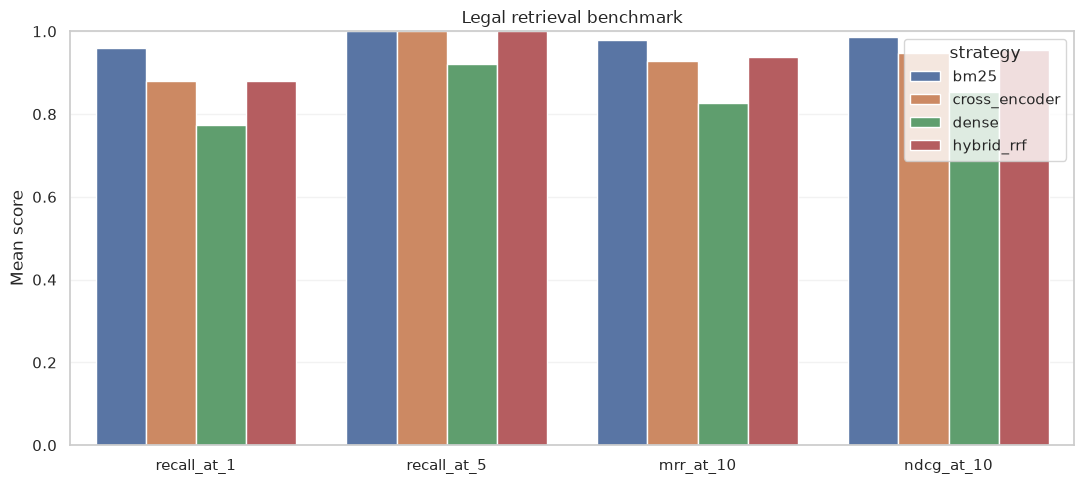

Saved: /data2/user_data/sg57092c/LLM_finetune/artifacts/hybrid_legal_retrieval/evaluation/retrieval_strategy_comparison.png


In [17]:
plot_data = overall_metrics.melt(
    id_vars="strategy",
    value_vars=["recall_at_1", "recall_at_5", "mrr_at_10", "ndcg_at_10"],
    var_name="metric",
    value_name="score",
)
fig, axis = plt.subplots(figsize=(11, 5))
sns.barplot(data=plot_data, x="metric", y="score", hue="strategy", ax=axis)
axis.set_ylim(0, 1)
axis.set_title("Legal retrieval benchmark")
axis.set_xlabel("")
axis.set_ylabel("Mean score")
axis.grid(axis="y", alpha=0.25)
fig.tight_layout()
figure_path = EVALUATION_DIR / "retrieval_strategy_comparison.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", figure_path)



## 16. Failure analysis



In [18]:
reranked_failures = evaluation_df[
    (evaluation_df["strategy"] == "cross_encoder")
    & (evaluation_df["relevant_rank"] == 0)
][["query_id", "partition", "jurisdiction"]]
reranked_failures = reranked_failures.merge(
    queries_df[["query_id", "query", "relevant_judgment_hash"]],
    on="query_id",
    how="left",
)
print("Cross-encoder failures outside top 10:", len(reranked_failures))
display(reranked_failures.head(10))

best_strategy = overall_metrics.sort_values(
    ["recall_at_5", "mrr_at_10"], ascending=False
).iloc[0]
print(
    f"Best strategy by Recall@5 then MRR@10: {best_strategy['strategy']} "
    f"(Recall@5={best_strategy['recall_at_5']:.3f}, "
    f"MRR@10={best_strategy['mrr_at_10']:.3f})"
)



Cross-encoder failures outside top 10: 0


,query_id,partition,jurisdiction,query,relevant_judgment_hash


Best strategy by Recall@5 then MRR@10: bm25 (Recall@5=1.000, MRR@10=0.980)


## 17. Interactive retrieval example



In [ ]:
example_query = (
    "What principles determine whether a statutory authority may cancel a land allotment?"
)
example_results = retrieve(example_query, final_top_k=5)["cross_encoder"]
display(pd.DataFrame([
    {
        "rank": result["rank"],
        "dataset": result["dataset"],
        "case_id": result["case_id"],
        "jurisdiction": result["jurisdiction"],
        "reranker_score": result["score"],
        "text_preview": result["text"][:500],
    }
    for result in example_results
]))

,rank,dataset,case_id,jurisdiction,reranker_score,text_preview
0,1,IN-Abs,5055,India,4.056008,"(3) Where any condition imposed in an order of allotment is not complied with by the allottee, the State Government shall, after giving an opportunity to th..."
1,2,IN-Abs,1181,India,3.756989,He then contends that the provisions of section 19(1) of the Act being subject to rules made under the Act must be read along with r. 102 which deals with c...
2,3,IN-Abs,1291,India,3.610373,"The result is that an allotment of such land can be cancelled only in the circumstances specified in that sub rule. Therefore, subsequent to July 22, 1952 t..."
3,4,IN-Abs,508,India,3.350825,or a mutual exchange with such other available property ; ( d ) in accordance with any general or special order of the central government ; 106 826 provided...
4,5,IN-Abs,1175,India,3.287721,Rule 14 of the Rules narrates the grounds on which an allotment can be cancelled and also the procedure to be followed for cancelling such an allotment. If ...


## 18. Save pipeline configuration and handoff



In [20]:
pipeline_report = {
    "dense_model": DENSE_MODEL_NAME,
    "reranker_model": RERANKER_MODEL_NAME,
    "corpus_chunks": len(corpus_df),
    "corpus_judgments": int(corpus_df["judgment_hash"].nunique()),
    "retrieval_chunk_tokens": effective_chunk_tokens,
    "retrieval_chunk_overlap": RETRIEVAL_CHUNK_OVERLAP,
    "dense_candidates": DENSE_CANDIDATES,
    "bm25_candidates": BM25_CANDIDATES,
    "rrf_k": RRF_K,
    "rerank_top_n": RERANK_TOP_N,
    "final_top_k": FINAL_TOP_K,
    "benchmark_queries": len(queries_df),
    "case_limit_per_partition": CASE_LIMIT_PER_PARTITION,
    "best_strategy": best_strategy["strategy"],
    "best_recall_at_5": float(best_strategy["recall_at_5"]),
    "best_mrr_at_10": float(best_strategy["mrr_at_10"]),
    "index_config": index_config,
}
with open(ARTIFACT_DIR / "retrieval_pipeline_report.json", "w", encoding="utf-8") as file:
    json.dump(pipeline_report, file, indent=2)

print("Index artifacts:", INDEX_DIR)
print("Evaluation artifacts:", EVALUATION_DIR)



Index artifacts: /data2/user_data/sg57092c/LLM_finetune/artifacts/hybrid_legal_retrieval/index
Evaluation artifacts: /data2/user_data/sg57092c/LLM_finetune/artifacts/hybrid_legal_retrieval/evaluation


## 19. Next stage

Notebook 07 should consume the saved hybrid retriever and implement the
multi-agent RAG workflow:

- **Query agent:** classifies jurisdiction, intent and required metadata filters.
- **Retrieval agent:** executes dense + BM25 + RRF retrieval.
- **Reranking agent:** applies the Cross-Encoder and selects evidence.
- **Summarization agent:** uses the Qwen3 QLoRA adapter with retrieved evidence.
- **Verification agent:** checks citation support, contradictions and abstention.

Before connecting generation, prefer a retrieval configuration with strong
Recall@5 and MRR@10 on every jurisdiction, not only strong overall performance.
